<a href="https://colab.research.google.com/github/Bethimen/EML_GRUPO11_25-26/blob/main/eml_k_bandit-main/bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit con brazos de tipo bernoulli


*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy, softmax y ucb1 en un problema de k-armed bandit con brazos de tipo bernoulli.
Se generan gráficas de recompensas promedio, selección del brazo óptimo, regret acumulado y estadísticas por brazo (una cada vez) para cada algoritmo.

## Preparación del entorno


In [1]:
#@title Importamos todas las clases y funciones

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, Softmax, UCB1
from arms import ArmBernoulli, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


## Experimento


Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio, selección del brazo óptimo, regret acumulado y estadísticas de los brazos.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan tres algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recompensas obtenidas en esas 500 veces.

In [2]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret_accumulated = np.zeros((len(algorithms), steps)) # Matriz de arrepentimiento acumulado

    arm_stats = [
        {
            "reward_sum": np.zeros(len(bandit.arms)), # Suma de premios en cada brazo
            "selections": np.zeros(len(bandit.arms)), # Número de veces que se selecciona cada brazo
            "optimal_arm": bandit.optimal_arm # Número del brazo óptimo
        }
        for _ in algorithms # Lo crea tantas veces por algoritmos tengamos
    ]

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        q_star = current_bandit.get_expected_value(current_bandit.optimal_arm) # q_star es el valor esperado del mejor brazo

        regret_per_run = np.zeros((len(algorithms), steps)) # Matriz de arrepentimiento por run

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                if chosen_arm == optimal_arm: # Si el brazo elegido es el óptimo
                    optimal_selections[idx, step] += 1 # Aumenta en 1 el número de selecciones óptimas en cada paso

                regret = q_star - reward # El arrepentimiento es el valor esperado del mejor brazo - la recompensa del brazo actual

                if step == 0:
                    regret_per_run[idx, step] = regret # En el primer paso cogemos el arrepentimiento actual
                else:
                    regret_per_run[idx, step] = (regret_per_run[idx, step - 1] + regret) # En los siguientes pasos el arrepentimiento el arrepentimiento acumulado más el arrepentimiento del paso actual

                arm_stats[idx]["selections"][chosen_arm] += 1 # Se aumenta el número de selecciones a 1 del brazo elegido por algoritmo
                arm_stats[idx]["reward_sum"][chosen_arm] += reward # Se suma todos los premios del brazo elegido por algoritmo

        regret_accumulated += regret_per_run # Regret acumulado por run

    rewards /= runs # Promedio de las recompensas

    optimal_selections = (optimal_selections / runs) * 100 # Saca el porcentaje de selección óptima de cada algoritmo en cada paso

    regret_accumulated /= runs # Promedio del arrepentimiento

    return rewards, optimal_selections, regret_accumulated, arm_stats


## Ejecución del experimento


Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan:
- Tres algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.
- Tres algoritmos softmax para valores tau: 0.2, 0.5 y 1.0.
- Tres algoritmos UCB1 para valores coeficiente: 0.0, 1.41 y 4.0.

In [3]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithmsEpsilon = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Definir los algoritmos a comparar. En este caso son 3 algoritmos Softmax con diferentes valores de tau.
algorithmsSoftmax = [Softmax(k=k, tau=0.2), Softmax(k=k, tau=0.5), Softmax(k=k, tau=1.0)]

# Definir los algoritmos a comparar. En este caso son 3 algoritmos UCB1 con diferentes valores de c.
algorithmsUCB1 = [UCB1(k=k, c=0.0), UCB1(k=k, c=1.41), UCB1(k=k, c=4.0)]

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsEpsilon, optimal_selections_Epsilon, regret_accumulated_Epsilon, arm_stats_Epsilon = run_experiment(bandit, algorithmsEpsilon, steps, runs)

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsSoftmax, optimal_selections_Softmax, regret_accumulated_Softmax, arm_stats_Softmax = run_experiment(bandit, algorithmsSoftmax, steps, runs)

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsUCB1, optimal_selections_UCB1, regret_accumulated_UCB1, arm_stats_UCB1 = run_experiment(bandit, algorithmsUCB1, steps, runs)


Bandit with 10 arms: ArmBernoulli(p=0.22), ArmBernoulli(p=0.48), ArmBernoulli(p=0.38), ArmBernoulli(p=0.32), ArmBernoulli(p=0.12), ArmBernoulli(p=0.12), ArmBernoulli(p=0.08), ArmBernoulli(p=0.44), ArmBernoulli(p=0.32), ArmBernoulli(p=0.37)
Optimal arm: 2 with expected reward=0.48


## Visualización de los resultados

Aquí visualizaremos cuatro tipo de gráficas:
- Recompensa promedio con respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Selección de brazo óptimo respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Regrets acumulados respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Estadísticas de cada brazo: 9 gráficas en total, tres por algoritmo, una por parámetro epsilon, tau o coeficiente.

### Análisis previo sobre los 3 primeros tipos de gráficas

En cuanto a las imágenes de los 3 primeros tipos de gráfica tendremos en cuenta lo siguiente:

1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Tres líneas de colores distintos representan diferentes valores de $\tau$ en el algoritmo Softmax:**
   - **Azul ($\tau$ = 0.2):** Representa una estrategia de **temperatura baja**, lo que genera una distribución de probabilidad altamente concentrada en el brazo con mayor valor estimado. Esto hace que el algoritmo tenga un comportamiento **explotador**
   - **Naranja ($\tau$ = 0.5):** Representa una estrategia de **temperatura media**, lo que hace que haya una distribución de probabilidad más equilibrada entre los brazos, adquiriendo un equilibrio de comportamiento **explorador** y **explotador**
   - **Verde ($\tau$ = 1.0):** Representa una estrategia de **temperatura alta**, haciendo que se suavice mucho la diferencia entre valores estimados, haciendo que el algoritmo adquiera un comportamiento mucho más **explorador**.

3. **Tres líneas de colores distintos representan diferentes valores de coeficiente en el algoritmo UCB1:**
   - **Azul (c = 0.0):** Representa una estrategia completamente elitista haciendo que sea **explotadora**, seleccionando únicamente el brazo con mejor valor estimado.
   - **Naranja (c = 1.41):** Representa una estrategia más equilibrada de **exploración** y **explotación**, aumentando la selección de brazos menos visitados.
   - **Verde (c = 4.0):** Representa una estrategia de **exploración** muy alta, haciendo que al algoritmo le de menos importancia al valor estimado e intente seleccionar brazos menos visitados.

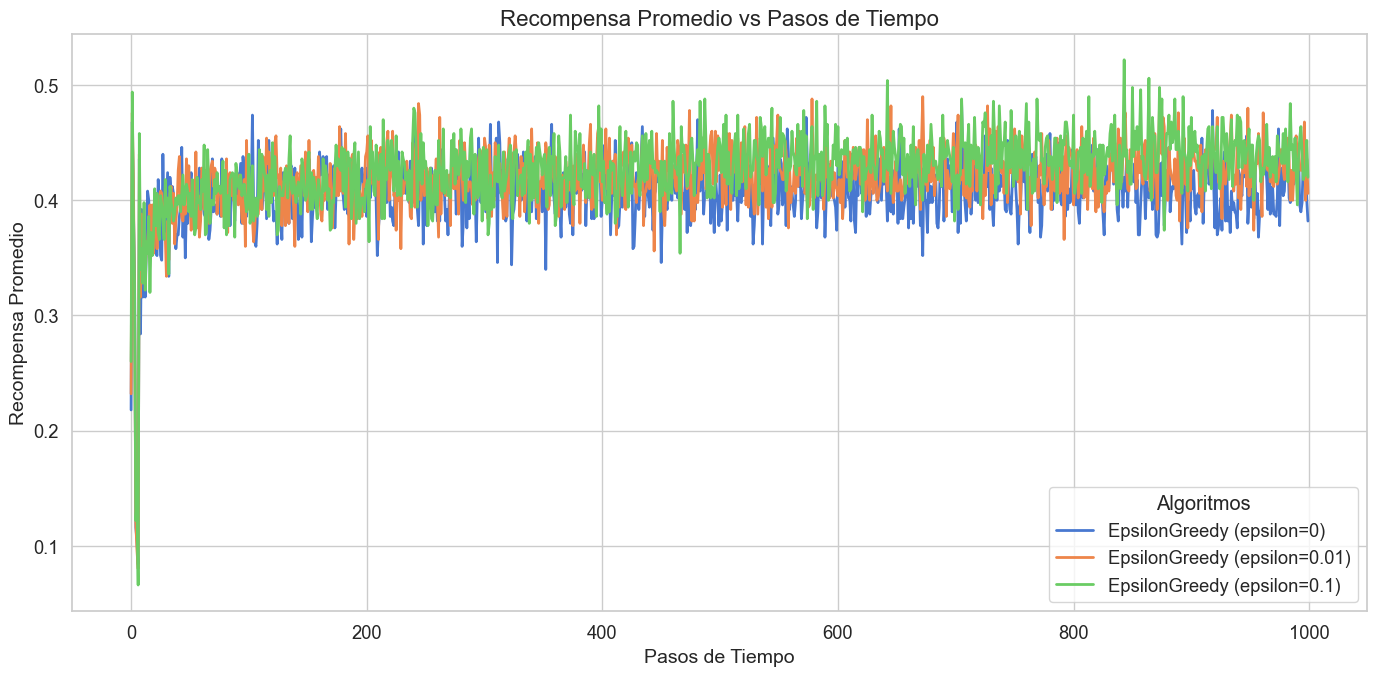

In [4]:

# Graficar los resultados
plot_average_rewards(steps, rewardsEpsilon, algorithmsEpsilon)


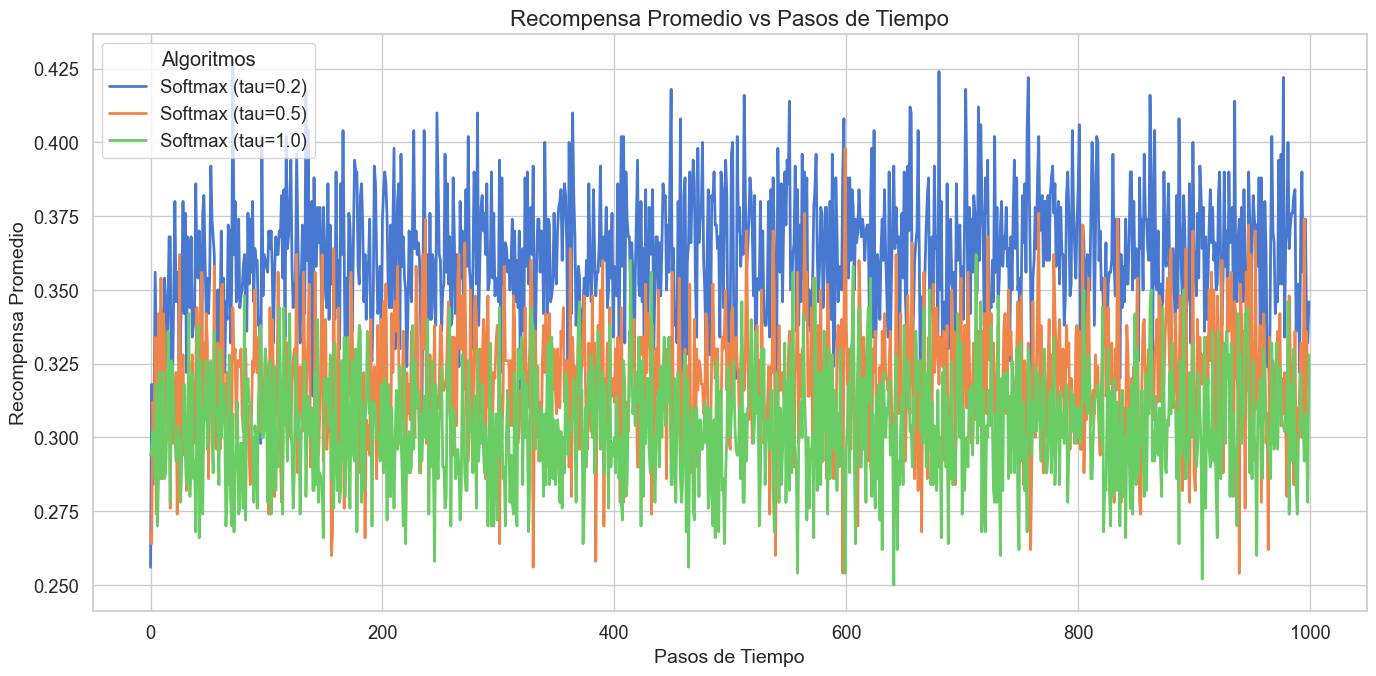

In [5]:

# Graficar los resultados
plot_average_rewards(steps, rewardsSoftmax, algorithmsSoftmax)

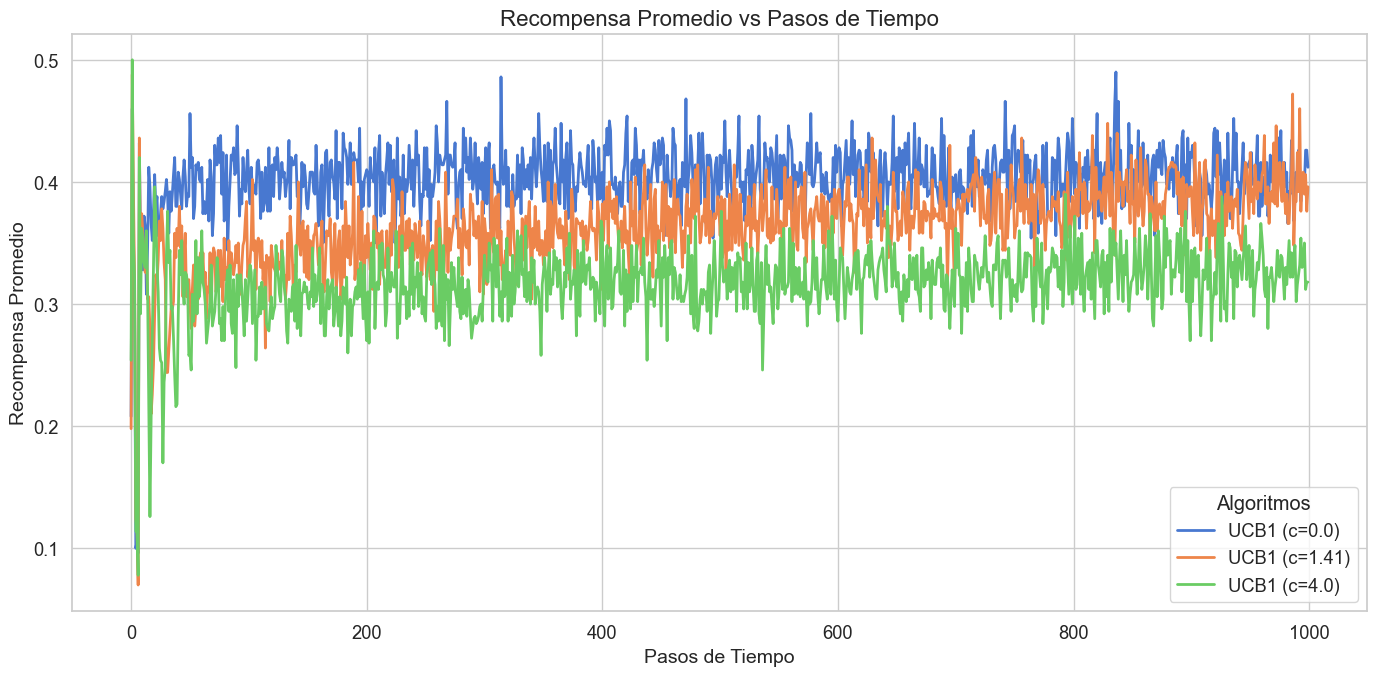

In [6]:

# Graficar los resultados
plot_average_rewards(steps, rewardsUCB1, algorithmsUCB1)

### Análisis detallado sobre la recompensa promedio vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido Bernoulli. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo:

1. **Crecimiento de la recompensa promedio en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En el entorno **Bernoulli**, podemos ver que tanto la línea **azul (ε=0)**, la línea **naranja (ε=0.01)** y la línea **verde (ε=0.1)**, son muy parecidas, aunque con máximas superiores en algunos tramos de la configuración de **exploración** del 10%, dándonos a entender que la exploración ayuda a seleccionar brazos que inicialmente tenían un valor estimado menor, pero que poseen mayores **probabilidades** de éxito.

2. **Crecimiento de la recompensa promedio en el algoritmo Softmax:**

   La línea **azul ($\tau$=0.2)**, **naranja ($\tau$=0.5)** y **verde ($\tau$=1.0)**

   - La línea **azul ($\tau$=0.2)** con temperatura baja, muestra que la recompensa promedio se mantiene aproximadamente entre 0.325 y 0.425, indicando que su carácter explotador consigue resultados razonables. Aunque no muestra una mejora clara, señalar que el factor de **exploración** es lo suficientemente bajo como para limitar seleccionar otros brazos con mejores recompensas promedio.

   - La línea **naranja ($\tau$=0.5)** con temperatura media, muestra que pese a tener más **exploración** que la línea azul, muestre menores recompensas promedio, debido a que al **explorar** más brazos no **explota** lo suficiente brazos con mejor recompensa promedio

   - La línea **verde ($\tau$=1.0)** con temperatura alta, muestra de nuevo el análisis que hemos hecho en la línea naranja, pese a aumentar su exploración su recompensa promedio baja porque selecciona brazos con menores **probabilidades**.

3. **Crecimiento de la recompensa promedio en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En la línea **naranja c=1.41** podemos que sus recompensas promedio en los primeros pasos son inferiores a las de la línea azul, demuestra un interesante crecimiento en la pendiente de la línea, mostrándonos que este equilibrio entre **explotación** y **exploración** hace que el algoritmo vaya encontrando mejores brazos que al principio tenían menor valor estimado, y al darles la oportunidad de ser utilizados, se revaloriza sus estimaciones, dando así la oportunidad de ser explotados y obtener mejores recompensas promedio.

   En la línea **verde(c=4.0)**, aunque al principio era la peor línea de las 3, con el tiempo demuestra tener un crecimiento que lo hace tener mayor potencial que la línea **azul c=0.0**, demostrándonos de nuevo que al tener una alta **exploración** ayuda al algoritmo a seleccionar brazos con mejores probabilidades.

   En la línea **azul c=0.0**, empieza siendo la línea mayor recompensa promedio del gráfico, pero a lo largo del tiempo no muestra un crecimiento, lo que parece indicar un estancamiento que hace que al no explorar lo suficiente otros brazos no tenga muchas oportunidades de crecer.

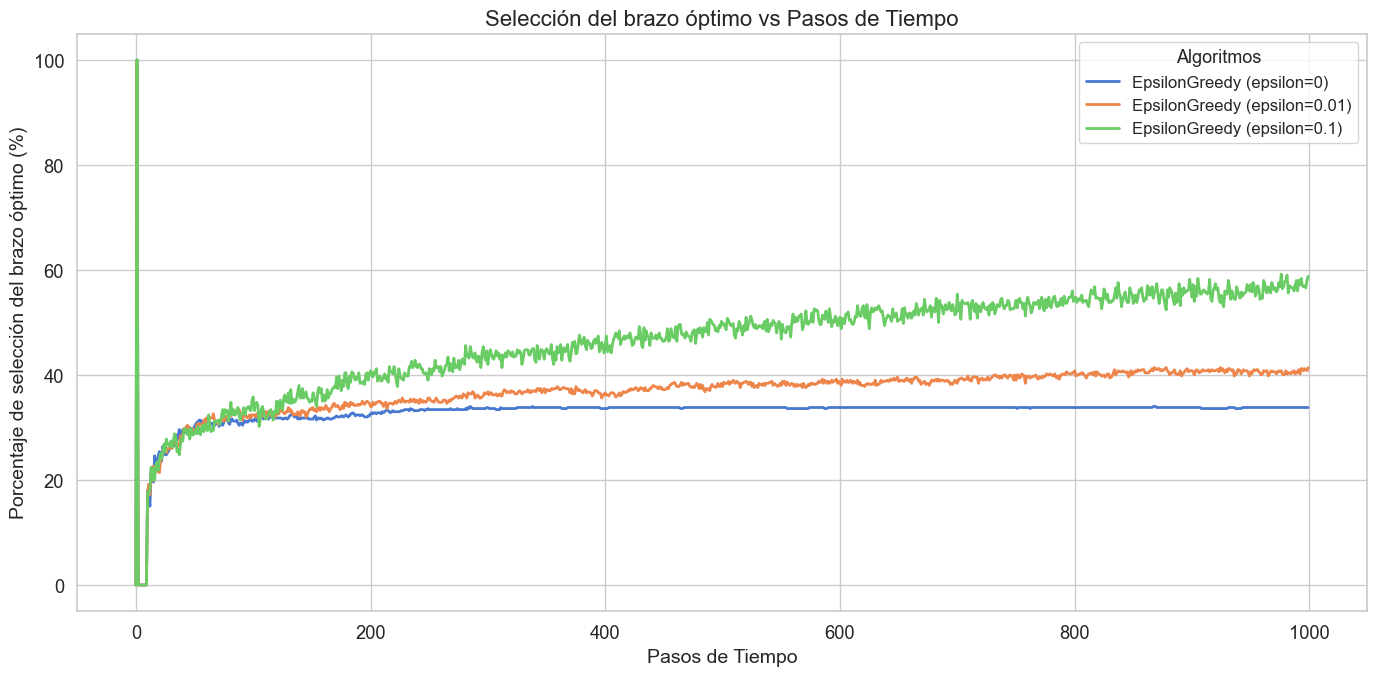

In [7]:
plot_optimal_selections(steps, optimal_selections_Epsilon, algorithmsEpsilon)

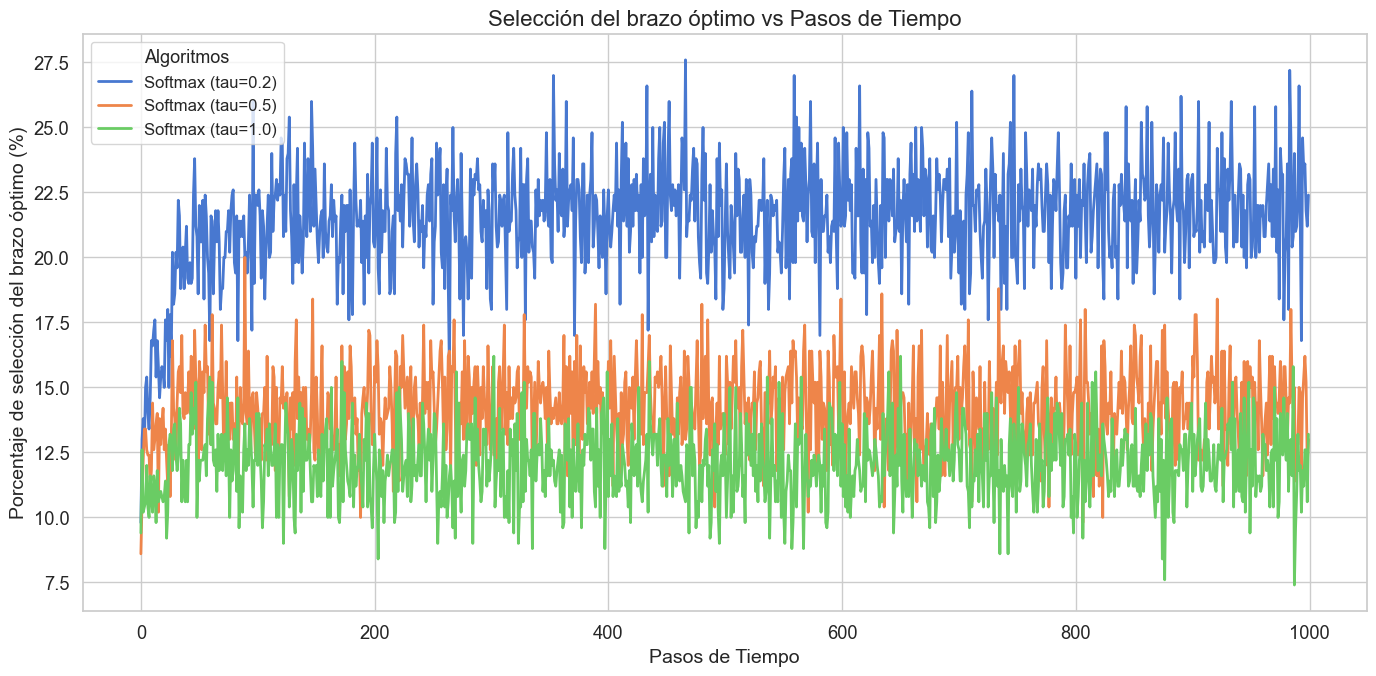

In [8]:
plot_optimal_selections(steps, optimal_selections_Softmax, algorithmsSoftmax)

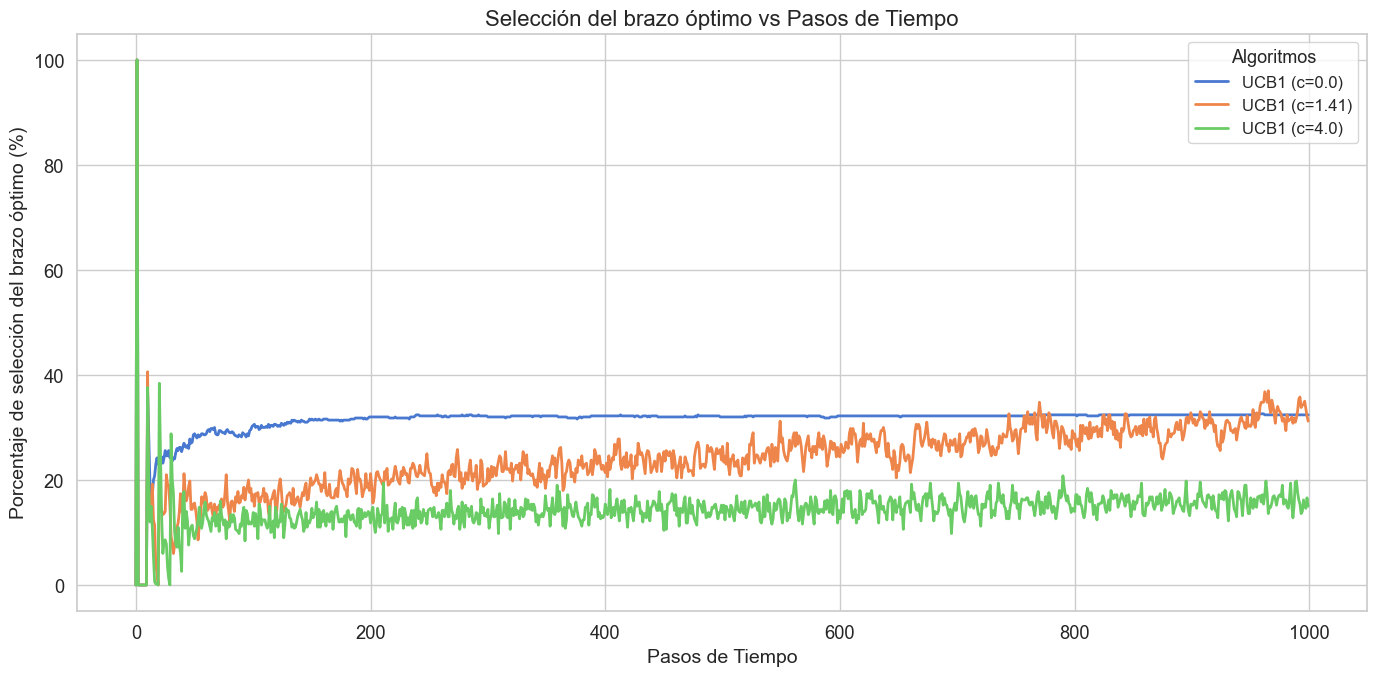

In [9]:
plot_optimal_selections(steps, optimal_selections_UCB1, algorithmsUCB1)

### Análisis detallado sobre la selección del brazo óptimo vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Selección del brazo óptimo vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido Bernoulli. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de selección del brazo óptimo** obtenido por cada algoritmo:

1. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En la línea **verde (ε=0.1)**, podemos ver un crecimiento de la pendiente a lo largo de los pasos de tiempo, mostrándonos que la **exploración** del 10% ayuda a que el algoritmo seleccione con más facilidad el brazo óptimo, posiblemente porque muestra un valor estimado bajo.

   En la línea **naranja (ε=0.01)** con 1% de **exploración**, podemos ver como también hay un crecimiento en la línea, demostrando de nuevo que el factor de **exploración** ayuda mucho al algoritmo a encontrar el brazo óptimo pese a solo ser un 1%.

   En la línea **azul (ε=0)** podemos ver como al principio había algún crecimiento, pero la línea se mantiene constante en gran parte de la gráfica, demostrando que con un enfoque **explotador** el algoritmo se atasca impidiéndole seleccionar más veces el brazo óptimo.

2. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo Softmax:**

   - La línea **azul ($\tau$=0.2)** con temperatura baja, podemos ver que aunque la línea crece de primeras, al final se atasca en un porcentaje de uso muy bajo, indicando que le falta más **exploración**

   - La línea **naranja ($\tau$=0.5)** con temperatura media, al tener un componente de **exploración** más equilibrado, el algoritmo selecciona otros brazos con mayor frecuencia, lo que reduce el porcentaje de selección del brazo óptimo.

   - La línea **verde ($\tau$=1.0)** con temperatura alta, demuestra que una configuración con mucha **exploración**, el algoritmo selecciona muchos brazos que no son el óptimo, lo que reduce considerablemente el porcentaje de selección del brazo óptimo.

3. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En la línea **naranja c=1.41**, se puede ver un crecimiento notable, demostrando que el equilibrio **explotación** y **exploración** ayuda a que el algoritmo explore brazos con estimaciones iniciales bajas, permitiendo identificar el brazo óptimo y **explotarlo** con mayor frecuencia.

   La línea **azul c=0.0** se puede ver como permanece constante a lo largo de los pasos de tiempo, debido a que el algoritmo no **explora** lo suficiente lo que hace que el algoritmo no seleccione con más frecuencia el brazo óptimo.

   La línea **verde(c=4.0)** se le ve un crecimiento muy ligero, lo que indica que con su alta **exploración**, pese a que selecciona otros brazos, también selecciona más veces el óptimo, lo que conlleva a un incremento que es apenas perceptible ya que no explota lo suficiente el brazo óptimo.

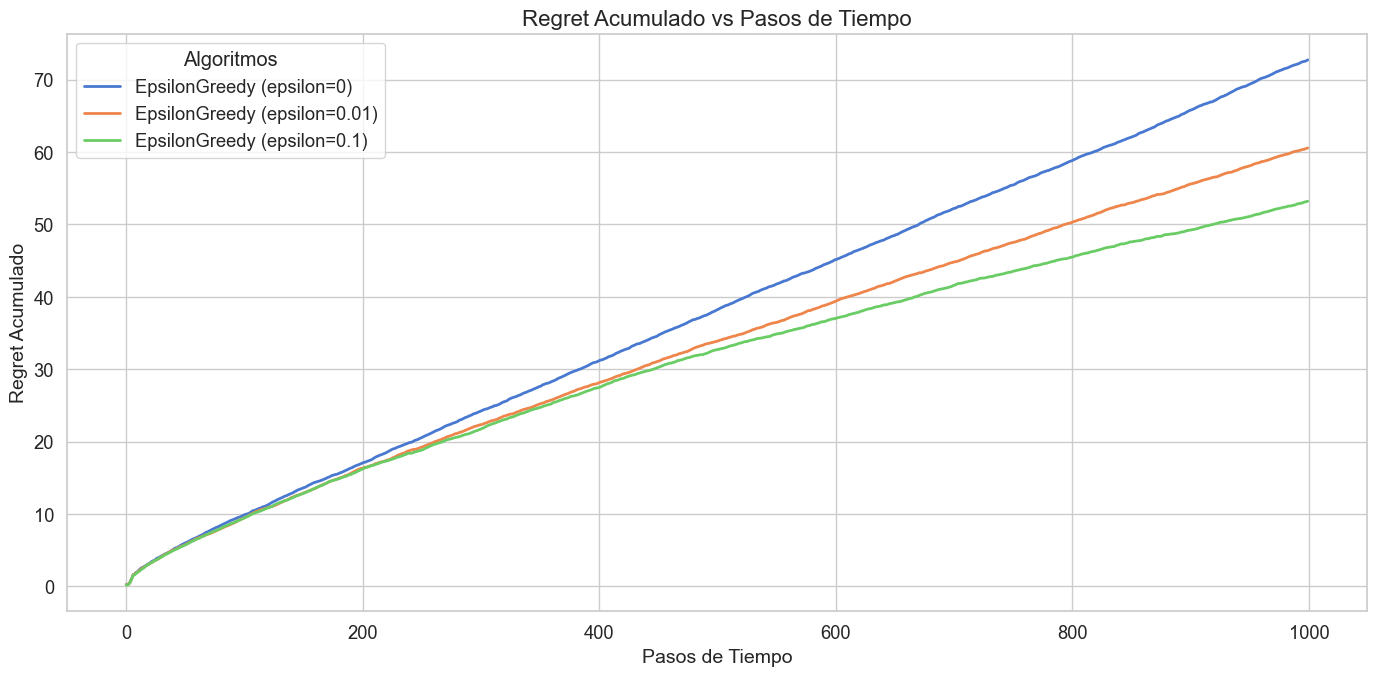

In [10]:
plot_regret(steps, regret_accumulated_Epsilon, algorithmsEpsilon)

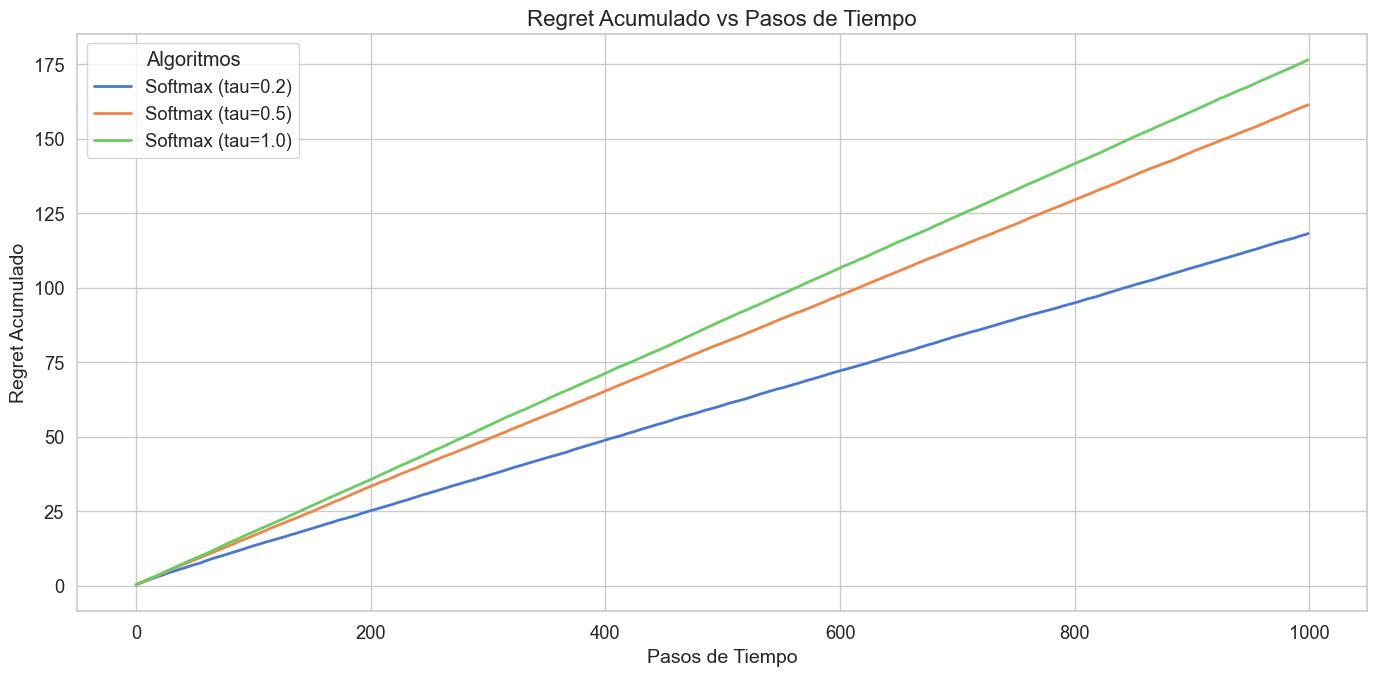

In [11]:
plot_regret(steps, regret_accumulated_Softmax, algorithmsSoftmax)

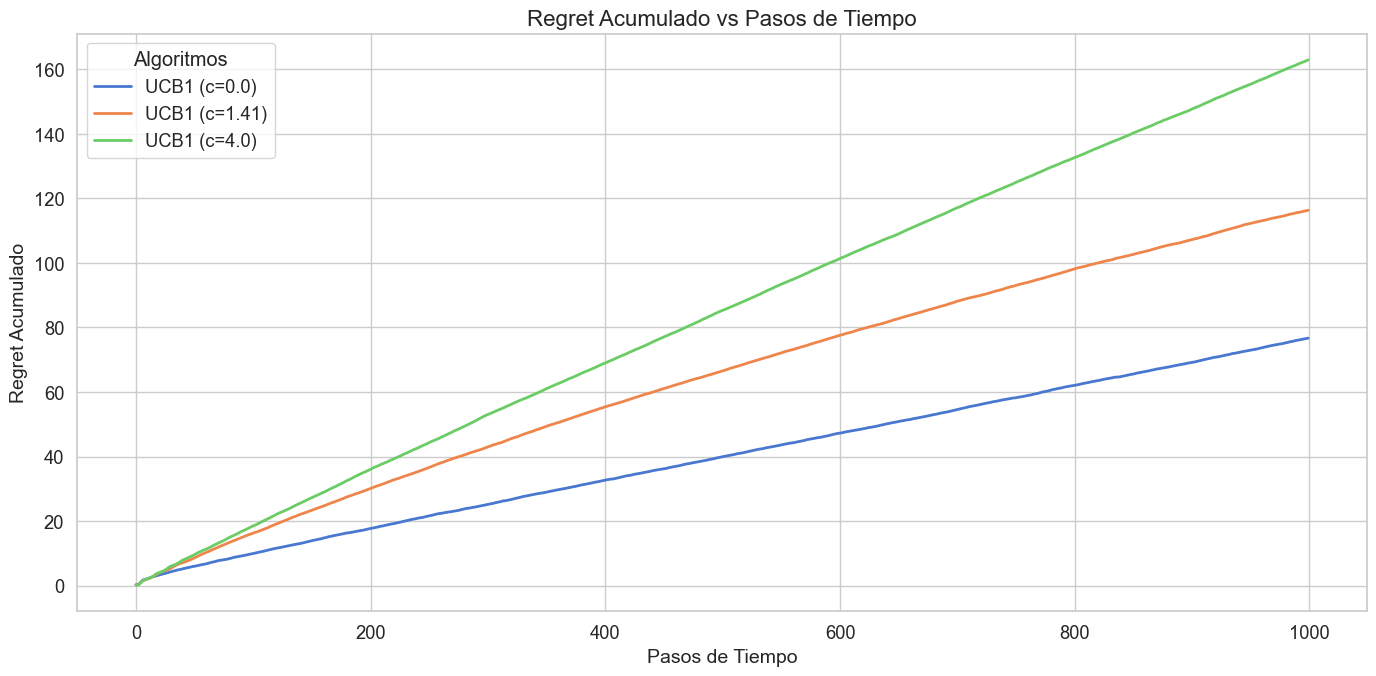

In [12]:
plot_regret(steps, regret_accumulated_UCB1, algorithmsUCB1)

### Análisis detallado sobre el regret acumulado vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Regret acumulado vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido Bernoulli. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **regret acumulado** obtenido por cada algoritmo:

1. **Crecimiento del regret acumulado en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva. Además se puede ver como el regret acumulado es poco más de 400, demostrando el correcto funcionamiento del algoritmo en esta situación.

   La línea **azul (ε=0)** demuestra una pendiente superior en regret acumulado debido a que el algoritmo al faltarle **exploración**, **explota** el brazo con mayor valor estimado el cual no es el brazo óptimo, haciendo que sea la línea que más regret acumule durante los pasos de tiempo.

   La linea **naranja (ε=0.01)** al tener un factor de **exploración** selecciona otros brazos que pueden ofrecer mejor recompensa promedio, y por lo tanto, el regret acumulado es menor.

   La línea **verde (ε=0.1)** presenta el menor regret acumulado debido a su mayor nivel de exploración, lo que le permite identificar el brazo óptimo con mayor rapidez.

2. **Crecimiento del regret acumulado en el algoritmo Softmax:**

   - La línea **verde ($\tau$=1.0)** al ser una temperatura alta, realiza una **exploración** muy intensa, que esto hace que el algoritmo seleccione otros brazos que pueden ofrecer al algoritmo, menos probabilidades de éxito.

   - La línea **naranja ($\tau$=0.5)** con temperatura media, su equilibrada **exploración** hace que el algoritmo explore brazos que puede quitar la atención a otros brazos que puedan ofrecer más probabilidades de éxito.

   - La línea **azul ($\tau$=0.2)** con temperatura baja, al ser una configuración más **explotadora** que **exploradora**, encuentra brazos iniciales que ofrecen buenas probabilidades de éxito.

3. **Crecimiento del regret acumulado en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   La línea **verde(c=4.0)** es la línea con mas crecimiento en regret acumulado de todas las configuraciones del algoritmo, esto se debe a que al tener mucha **exploración** el algoritmo selecciona más veces brazos que tienen menor probabilidad de éxito.

   En la línea **naranja c=1.41** se puede ver que tiene menos regret que la configuración de $c=4.0$ pero aún así su regret es el segundo que más crece, afirmando de nuevo que la **exploración** del algoritmo hace que se seleccionen brazos con menos probabilidad de éxito.

   La línea **azul c=0.0** que es más **explotadora** se puede ver como también crece, debido a que el algoritmo no explora lo suficiente otros brazos que puedan darle al algoritmo más probabilidad de éxito.

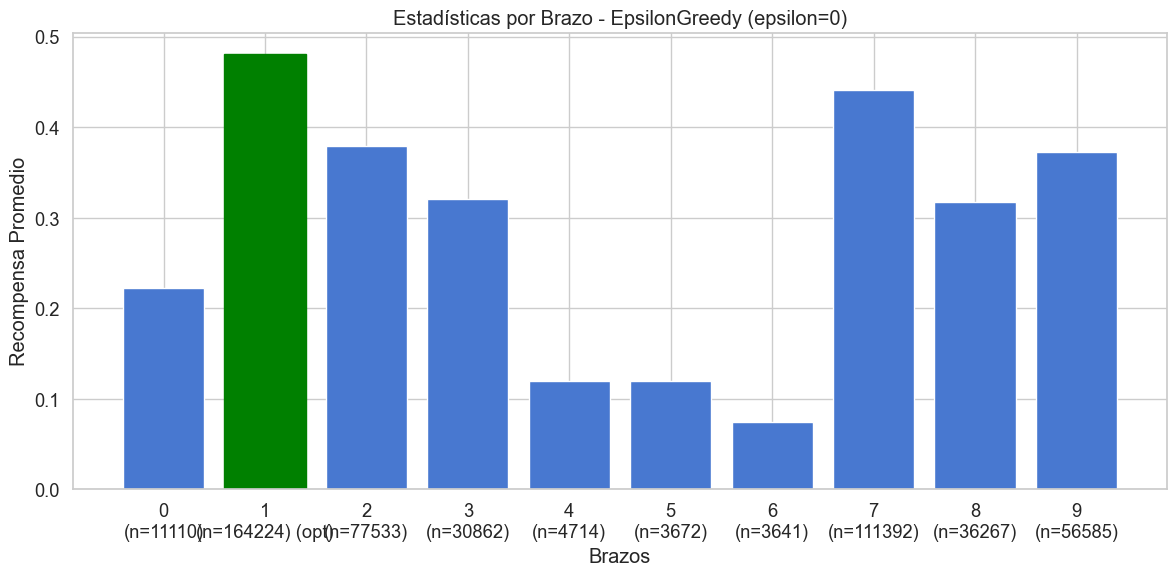

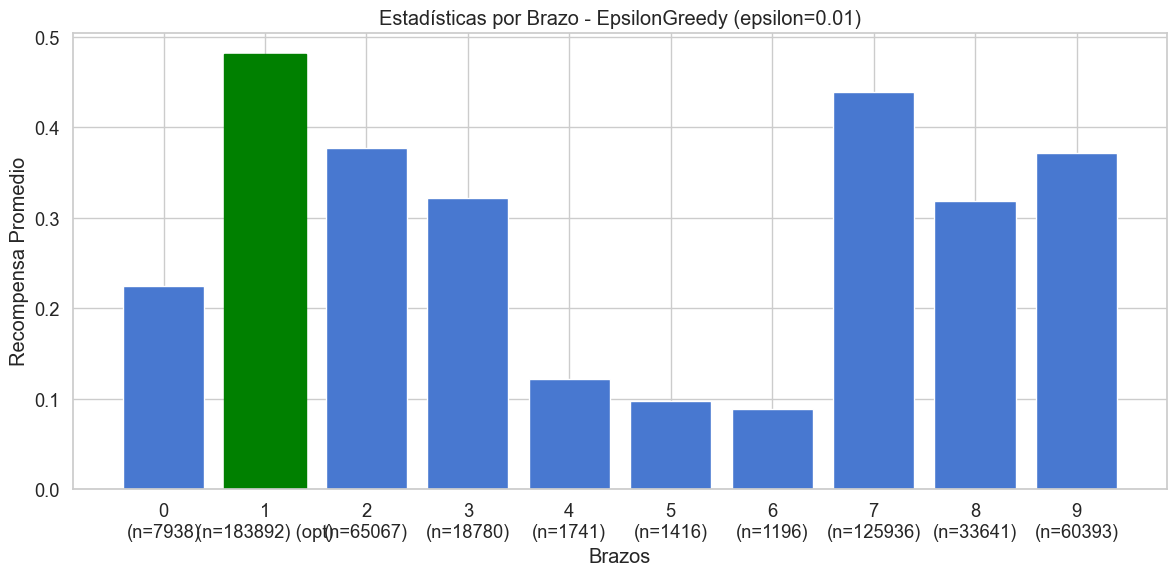

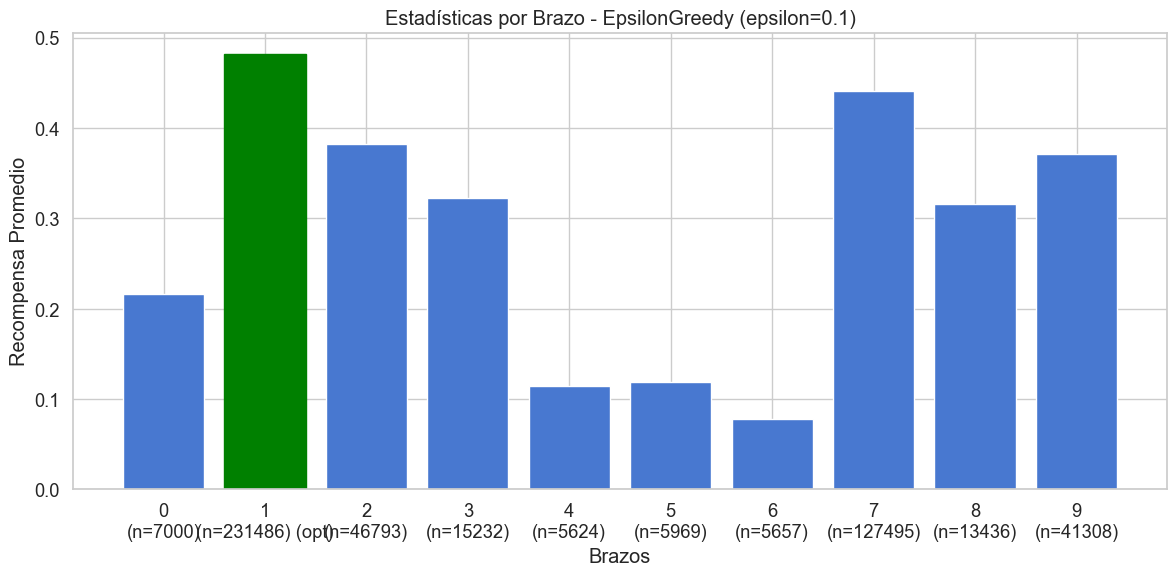

In [13]:
plot_arm_statistics(arm_stats_Epsilon, algorithmsEpsilon)

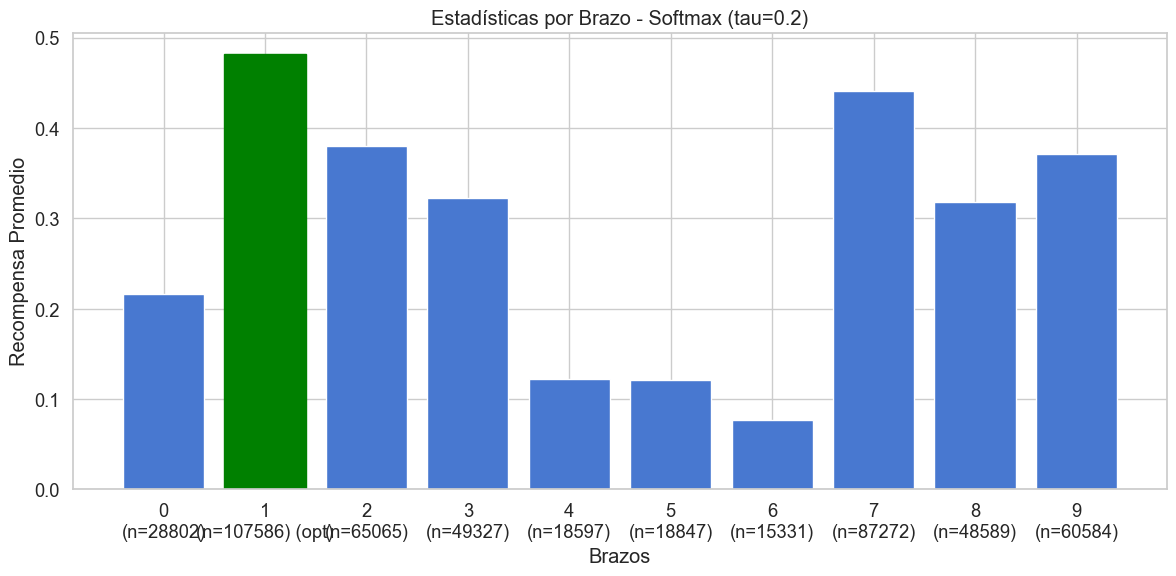

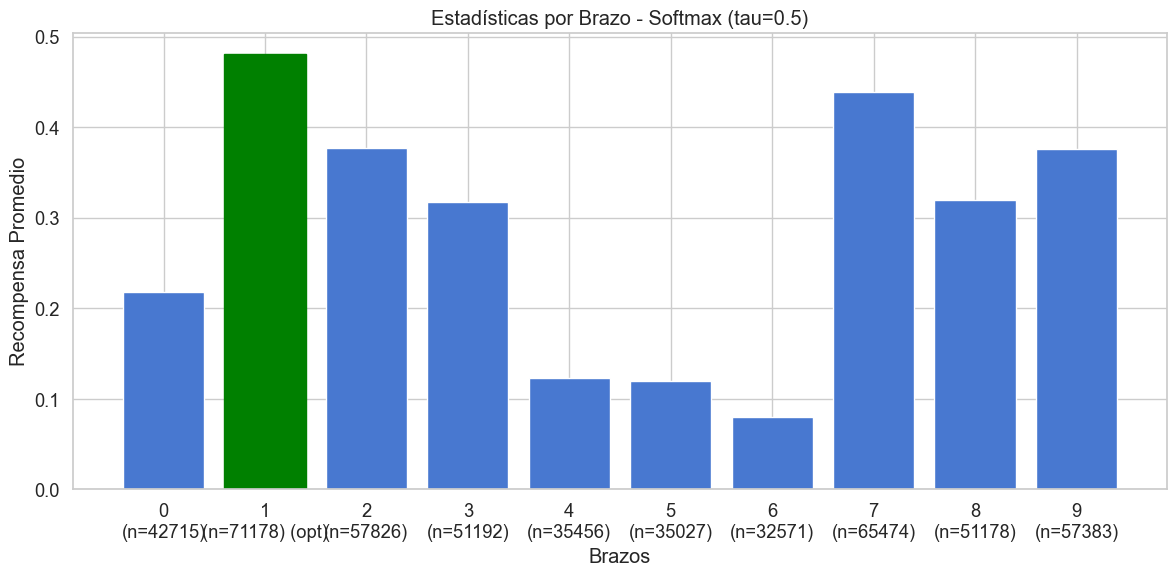

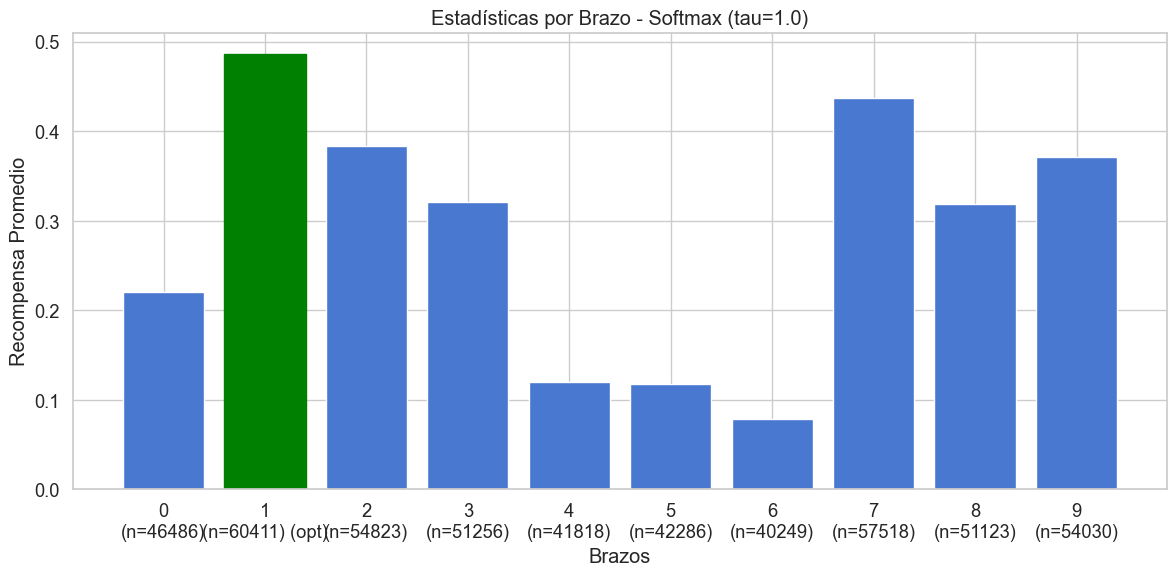

In [14]:
plot_arm_statistics(arm_stats_Softmax, algorithmsSoftmax)

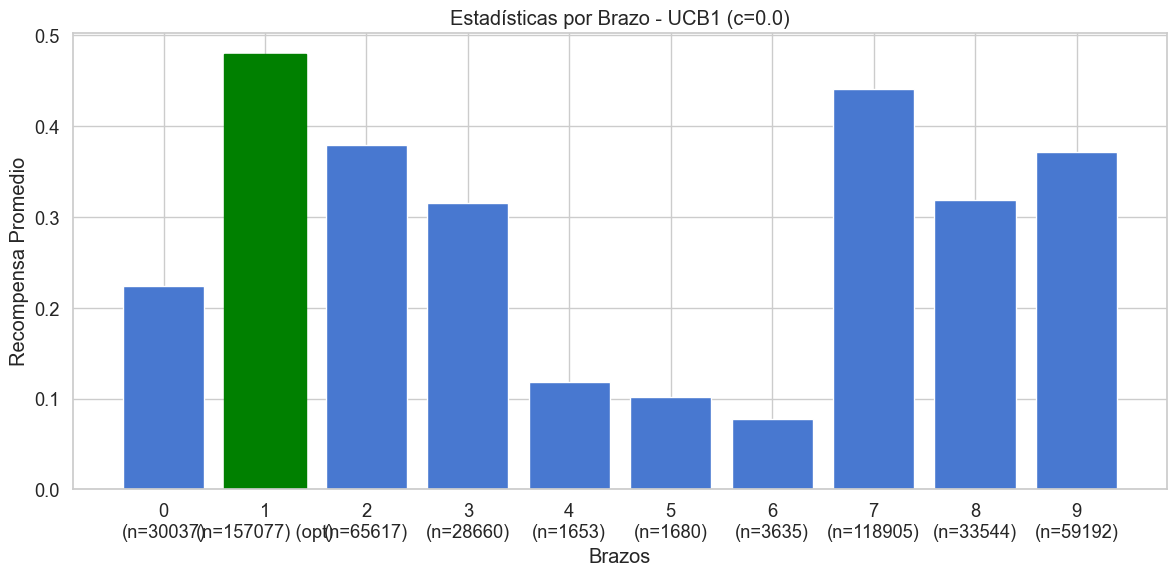

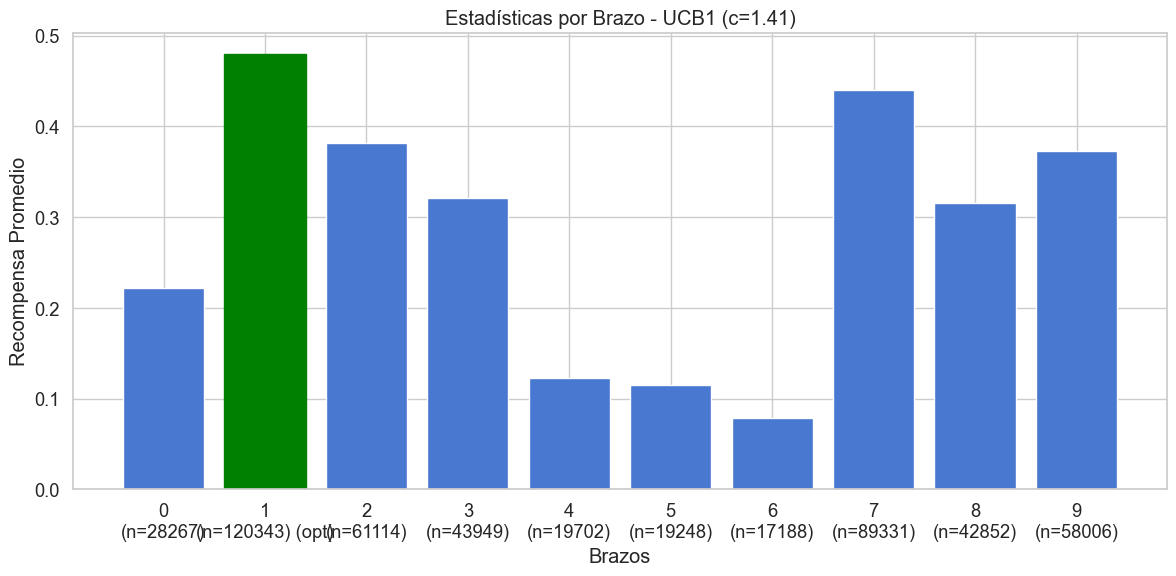

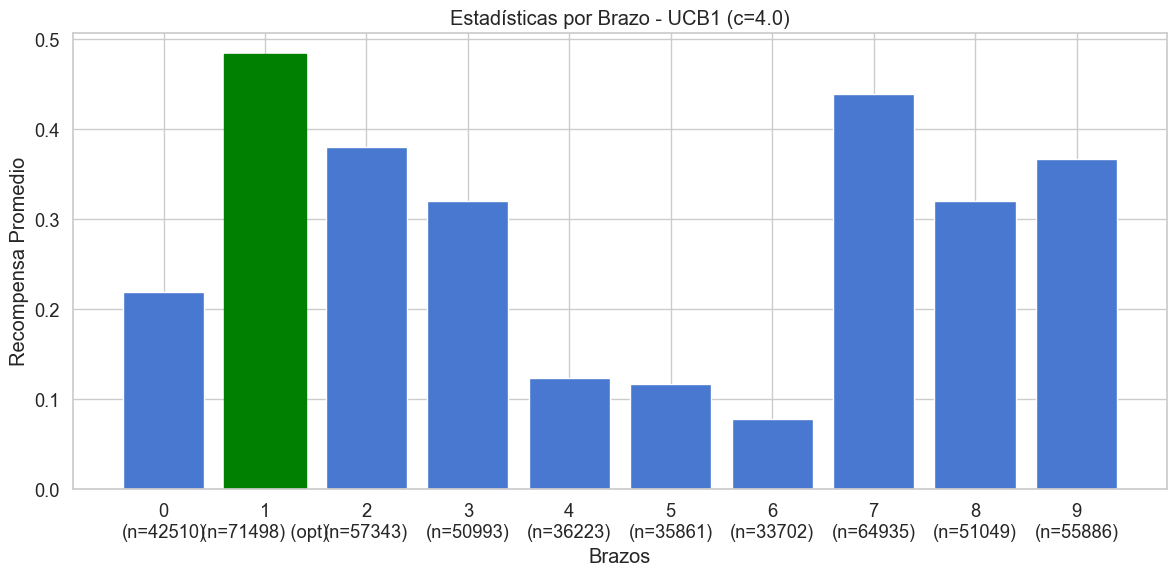

In [15]:
plot_arm_statistics(arm_stats_UCB1, algorithmsUCB1)

### Análisis detallado sobre las estadísticas por brazo

Las imágenes muestran un histograma titulado **"Estadísticas por Brazo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido Bernoulli. En el eje **x** se representan los **brazos**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada brazo en cada algoritmo. Hay que tener en cuenta que cada algoritmo con cada configuración es ejecutado 1000 pasos 500 runs, en las cuales la recompensa promedio varía entre algoritmos y configuraciones por el tipo de bandido en que los resultados pueden ser 0 ó 1. Además, colorearemos con color verde el brazo con mayor recompensa promedio para que sea más fácil de visualizar. También tenemos que tener en cuenta que el brazo óptimo es el brazo 1 ya que contiene más probabilidad y en segundo lugar el brazo 7. Ahora hablaremos de las estadísticas de cada brazo por cada algoritmo dependiendo de su ε, $\tau$ y $c$:

1. **Estadísticas por brazo en el algoritmo ε-Greedy:**

   En **ε=0** podemos ver como el algoritmo ha seleccionado 164224 veces el brazo óptimo y 111392 el algoritmo subóptimo con más recompensa promedio, haciéndonos ver que en un 55.12% de las veces se elegirá entre el óptimo o el siguiente más óptimo, siendo un 32.84% las veces que elige el brazo más óptimo lo que representa que esta estrategia **explotadora** solo selecciona un poco más de la mitad de las veces el brazo óptimo y subóptimo y casi un tercio de las veces el óptimo.

   En **ε=0.01** se selecciona el brazo óptimo 183892 veces y el siguiente más óptimo 125936 veces, siendo un 61.97% de las veces que se selecciona el brazo más óptimo o subóptimo y un 36.78% de veces que elige el brazo más óptimo lo que nos permite ver que con una **exploración** del 1% aumenta la probabilidad que elija el brazo óptimo y el brazo subóptimo, lo que significa enfocarse más en brazos con mayor valor estimado que seleccionar otros brazos.

   En **ε=0.1** se puede ver como se selecciona el brazo óptimo 231486 veces y el siguiente brazo más óptimo, 127495 veces, siendo un 71.80% de las veces que elegirá el brazo más óptimo o más subóptimo dependiendo de la recompensa promedio y un 46.30% las veces que se selecciona el brazo más óptimo. Esto nos sugiere que se elige bastante más veces el brazo óptimo y subóptimo al darle al algoritmo una configuración con más **exploración** lo que permite al algoritmo seleccionar más veces estos brazos.

2. **Estadísticas por brazo en el algoritmo Softmax:**

   En $\tau$=0.2 vemos como se selecciona 107586 el brazo óptimo y 87272 el brazo subóptimo con mayor recompensa promedio, siendo esto un 38.97% de selección para el brazo óptimo y subóptimo y un 21.52% la selección del brazo óptimo. Softmax con τ=0.2 es una estrategia bastante **explotadora**, por lo que depende fuertemente de las estimaciones iniciales. Si estas no reflejan correctamente la recompensa real de los brazos, el algoritmo puede quedar atrapado en brazos subóptimos durante gran parte de la ejecución.

   En $\tau$=0.5 el brazo óptimo se selecciona 71178 veces y el brazo más subóptimo en recompensa promedio un 65474 veces, siendo un 27.33% de las veces que se selecciona el brazo óptimo y subóptimo y un 14.24% de las veces que elige el brazo más óptimo. Con esto podemos ver como el algoritmo empeora en este caso al tener una estrategia más **exploradora** haciendo que se centre más en otros brazos que en el óptimo y subóptimo.

   En $\tau$=1.0 se puede ver como el brazo óptimo se selecciona 60411 veces y el brazo más subóptimo 57518 siendo esto un 23.59% de veces que se selecciona el brazo óptimo y subóptimo y un 12.08% las veces que se selecciona el brazo óptimo. Esto justifica una vez más lo que hemos visto con $\tau$=0.5 en este experimento, que el algoritmo funciona peor cuanto mayor **exploración** haga, lo que hace que el algoritmo seleccione brazos con menor probabilidad que la del óptimo.

3. **Estadísticas por brazo en el algoritmo UCB1:**

   En c=0.0 vemos como el brazo óptimo se selecciona 157077 veces y el brazo subóptimo 118905 veces, siendo esto un 55.20% de las veces que se selecciona el brazo óptimo y subóptimo y un 31.42% de las veces que se selecciona el brazo óptimo. Esto nos permite ver que el algoritmo con carácter mayormente **explotador** selecciona poco más de la mitad de las veces el brazo óptimo y subóptimo y menos del tercio de las veces el brazo óptimo, señalando que las diferencias de los valores estimados iniciales no son lo suficientemente grande entre brazos que va utilizando muchos brazos pese a estar enfocado el algoritmo a un carácter **explotador**

   En c=1.41 se selecciona el brazo óptimo 120343 y el brazo subóptimo 89331 veces, siendo esto un 41.93% de las veces que se selecciona el brazo óptimo y subóptimo, y un 24.07% las veces que selecciona el brazo óptimo. Esto indica que el algoritmo va seleccionando otros brazos aparte del óptimo sin **explotar** lo suficiente el óptimo y subóptimo.

   En c=4.0 podemos ver como se selecciona 71498 veces el brazo óptimo y 64935 veces el brazo subóptimo, siendo esto un 27.29% de las veces que el algoritmo selecciona el brazo óptimo y subóptimo y un 14.30% de las veces que selecciona el brazo óptimo. Aquí podemos observar que pese a tener una mayor **exploración** con esta configuración el algoritmo UCB1 se seleccionan menos veces el brazo óptimo y subóptimo, indicando que tener una configuración de **exploración** alta hace que el algoritmo se enfoque en seleccionar brazos subóptimos en vez del óptimo.

## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)** con el tipo de bandidos **Bernoulli**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado en el estudio del algoritmo epsilon-greedy, softmax y UCB1, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráficas generadas:

### **1. Epsilon-greedy**
En este experimento, hemos visto que el algoritmo epsilon-greedy prefiere un comportamiento más **explorador** ya que conforme aumenta este factor, el algoritmo es capaz de encontrar con más facilidad el brazo óptimo y acumular menos regret con el tiempo, indicando que el algoritmo explota brazos subóptimos, por lo que es necesario una **exploración** para seleccionar otros brazos con menor valor estimado y así encontrar con más facilidad mayor recompensa promedio.

### **2. Softmax**
En cuanto a este algoritmo, podemos ver que a menor temperatura el algoritmo encuentra con más facilidad el brazo óptimo, indicando que una configuración más explotadora, con baja temperatura, hace que el algoritmo seleccione con mayor frecuencia el brazo óptimo, obteniendo así mayor recompensa promedio y menor regret.

### **3. UCB1**
En este experimento, cuanto menor coeficiente $c$ mejor funciona el algoritmo UCB1, indicando que una exploración reducida permite seleccionar con mayor frecuencia el brazo óptimo, obteniendo mayor recompensa promedio y menor regret.

### **Comparación entre algoritmos**

Si comparamos los 3 algoritmos en este experimento, podemos ver que softmax es el que peor funciona debido a su menor recompensa promedio, a la no mejoría de selección de brazo óptimo a lo largo de los 1000 pasos en todas sus configuraciones y a su mayor regret acumulado.

En cuanto a epsilon-greedy y UCB1, los dos algoritmos con muy parecidos en eficacia, pero analizando en profundidad, el mejor algoritmo es epsilon-greedy, aparte de su gran recompensa promedio, podemos ver que es el algoritmo que experimenta un mayor crecimiento de selección de brazo óptimo a lo largo de los pasos de tiempo, además que es el que menos regret acumula en sus 3 configuraciones.